
# Predictia pretului locuintelor 
Scopul acestui notebook este de a construi si compara mai multi algoritmi de regresie care prezic pretul de vanzare al locuintelor, pe baza unor caracteristici structurale si geografice.

Voi analiza 8 modele diferite de regresie:
- Linear Regression: model simplu care prezice pretul locuintei pe baza unei relatii liniare intre caracteristici 
- K-Nearest Neighbors: prezice pretul in functie de preturile locuintelor cele mai apropiate ca si caracteristici
- Support Vector Machine: un algoritm care cauta o "linie" care sa separe datele intr-un mod care face diferenta intre exemplele corecte si cele gresite, chiar si in cazul relatiilor neliniare
- Decision Tree: imparte datele intr-un arbore de decizie, unde fiecare ramura reprezinta o decizie (de exemplu, daca locuinta are mai mult de 3 camere, se face o predictie mai mare pentru pret)
- Random Forest: foloseste mai multi arbori de decizie pentru a face o predictie mai precisa si mai robusta
- XGBoost: un algoritm care combina mai multe modele simple (arbori de decizie) pentru a obtine o performanta foarte buna in regresie
- CatBoost: algoritm de boosting similar cu XGBoost, dar care este optimizat special pentru datele categorice
- Explainable Boosting Machine (EBM): model de boosting explicabil, care ofera o intelegere clara a modului in care sunt luate deciziile si a impactului fiecarei caracteristici asupra predictiilor

Pe langa metrici, o sa folosesc si metode de interpretabilitate: SHAP, LIME si analiza incorporata a EBM.



In [14]:
import pandas as pd

# incarc datele si ma uit doar la primele 5 randuri ca sa vad in idee cum arata datele
df = pd.read_csv("./data/winequality-red.csv", delimiter=';')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Preprocesare date

In [15]:
# nu toate coloanele sunt relevante asa ca o sa le ignoram pe cele de care nu am nevoie si pun errors="ignore" ca sa nu dea eroare daca una dintre coloane lipseste
df = df.drop(columns=["sulphates", "chlorides"], errors="ignore")

# completez valorile lipsa: 
#     -daaca o coloana e de tip text (object), completez cu valoarea care apare cel mai des
#     -daca e numerica, completam cu valoarea de mijloc (mediana), ca sa nu fim influentati de extreme (gen preturi prea mari sau prea mici)
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# convertesc toate coloanele care au text (categorii) in coloane numerice, pentru ca modelele de ML nu inteleg textul
# folosesc pd.get_dummies() care transforma categoriile in 0 si 1 (de ex "Yes" devine 1, "No" devine 0) si setez drop_first=True ca sa evit duplicarea informatie
df = pd.get_dummies(df, drop_first=True)

## Împărțire în train/test și normalizare

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separ variabilele de intrare (X) de variabila pe care vrem sa o prezicem (y = "quality")
X = df.drop("fixed acidity", axis=1)
y = df["fixed acidity"]

# Aici creez un obiect StandardScaler care aduce toate valorile numerice la aceeasi scara (media = 0, deviatia standard = 1)
# E important pentru algoritmii care sunt sensibili la scala de ex: SVM, KNN
# fit_transform() invata din date si aplica transformarea
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Impart datele in doua bucati:
#    -80% merg in X_train, y_train pentru antrenare
#    -20% merg in X_test, y_test pentru testare
#random_state=42 garanteaza ca obtinem aceeasi impartire de fiecare data cand rulam codul 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Antrenarea modelelor de regresie

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0),
    "EBM": ExplainableBoostingRegressor()
}

# creez un dicționar cu toate modelele si fiecare cheie e numele modelului, iar valoarea e obiectul efectiv care poate fi antrenat
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train) #  antrenează modelul pe datele de train
    predictions[name] = model.predict(X_test) # face predicții pe datele de test

## Evaluarea modelelor

In [18]:
# MSE inseamna ca modelul greseste mult (si penalizeaza rau greselile mari)
# RMSE da o idee mai clara despre cat de departe sunt predicțiile de realitate, in medie
# MAE e simplu si util cand vrei doar sa vezi cu cat a gresit modelul in medie (fara sa exagereze cu penalizari)

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# functie care evalueaza un model si afiseaza scorurile
def eval_model(name, y_true, y_pred):
    
    # eroarea patratica medie (cat de mult greseste modelul in medie, dar erorile mari sunt penalizate mai tare)
    mse = mean_squared_error(y_true, y_pred)
    
    # radical din MSE, ca sa fie in aceeasi unitate ca pretul (dolari)
    rmse = np.sqrt(mse)
    
    # eroarea absoluta medie (cat greseste modelul in medie, dar toate greselile sunt tratate la fel)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"{name} -> MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# parcurgem toate modelele si afisam scorurile pentru fiecare
for name, y_pred in predictions.items():
    eval_model(name, y_test, y_pred)


# Analiza rezultate:
     # Cele mai bune modele:
         # CatBoost si EBM sunt cele mai performante, avand cele mai mici erori (MSE, RMSE, MAE)
         # Acestea sunt foarte bune pentru prezicerea preturilor si sunt explicabile

     # buna:
         # XGBoost si Random Forest sunt si ele foarte bune, avand erori mai mici decat modelele de baza

     #Modelele mai slabe:
         #SVM si KNN au performante mai slabe, cu erori mult mai mari. SVM, in special, nu s-a comportat bine pe acest set de date

#Concluzie:
     # Modelele de boosting (CatBoost, XGBoost) sunt cele mai eficiente in acest tip de problema
     # Modelele de baza (Linear Regression, KNN, SVM) sunt mai slabe in fata unui set de date complex

Linear Regression -> MSE: 0.38, RMSE: 0.61, MAE: 0.46
KNN -> MSE: 0.61, RMSE: 0.78, MAE: 0.56
SVM -> MSE: 0.43, RMSE: 0.65, MAE: 0.46
Decision Tree -> MSE: 0.65, RMSE: 0.80, MAE: 0.51
Random Forest -> MSE: 0.34, RMSE: 0.58, MAE: 0.42
XGBoost -> MSE: 0.31, RMSE: 0.55, MAE: 0.38
CatBoost -> MSE: 0.25, RMSE: 0.50, MAE: 0.37
EBM -> MSE: 0.29, RMSE: 0.53, MAE: 0.40


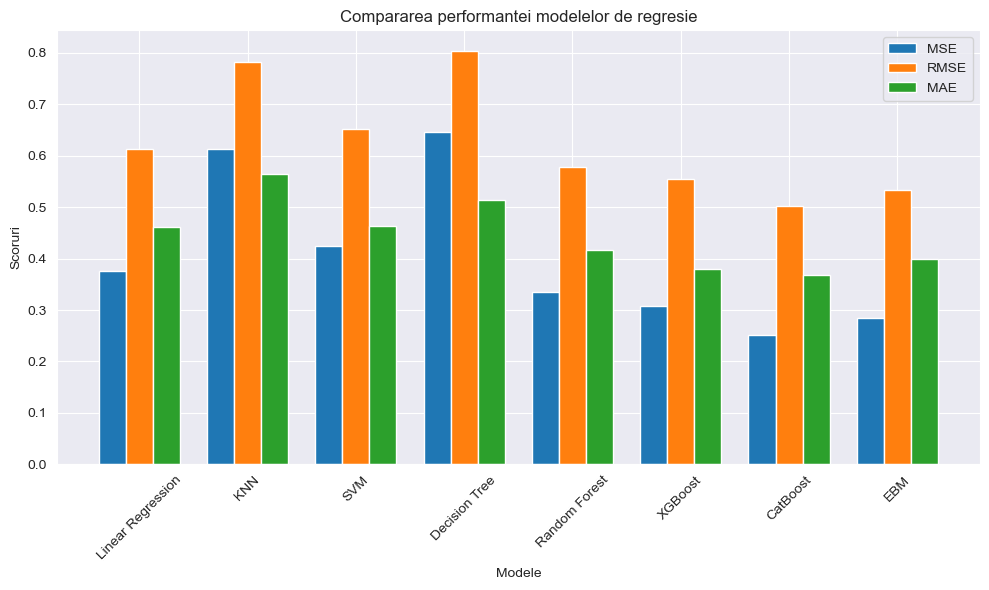

In [19]:
# am realizat si un grafic ca sa fie mai usor de observat diferentele intre modele

import matplotlib.pyplot as plt

# listez scorurile pentru MSE, RMSE si MAE
mse_scores = []
rmse_scores = []
mae_scores = []
model_names = []

# calzulez scorurile pt fiecare model
for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    model_names.append(name)

# generez grafic pentru compararea scorurilor
x = np.arange(len(model_names))  # pozitiile pentru modelele pe axa X

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.25  # latimea fiecarei bare
ax.bar(x - bar_width, mse_scores, bar_width, label='MSE')
ax.bar(x, rmse_scores, bar_width, label='RMSE')
ax.bar(x + bar_width, mae_scores, bar_width, label='MAE')

# adaug etichete si titluri
ax.set_xlabel('Modele')
ax.set_ylabel('Scoruri')
ax.set_title('Compararea performantei modelelor de regresie')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()

# afisez graficul
plt.tight_layout()
plt.show()

## Explicabilitate: SHAP și LIME

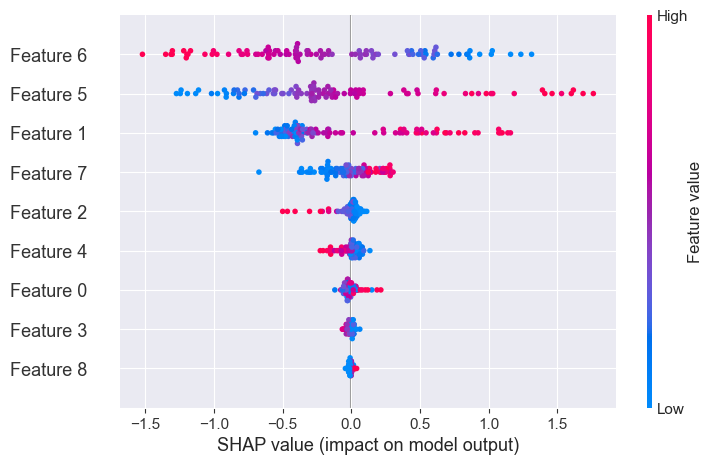

In [20]:
# Aici folosesc SHAP ca sa vad ce influenteaza cel mai mult predictiile modelului Random Forest
# SHAP ne arata cum contribuie fiecare feature (coloana din date) la predictia finala, pt fiecare observatie in parte
# Practic, vedem ce feature are cel mai mare impact asupra pretului prezis
# Graficul beeswarm afiseaza toate feature-urile si efectul lor (pozitiv sau negativ) asupra predictiilor

import shap

best_model = models["Random Forest"]
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test[:100])
shap.plots.beeswarm(shap_values)


In [10]:
# Aici folosesc LIME ca sa explic o singura predictie facuta de model
# LIME ia un exemplu (o casa din test set) si incearca sa explice cum modelul a ajuns la pretul prezis
# Practic, simuleaza un model simplu in jurul acelui exemplu si ne arata ce feature-uri au influentat cel mai mult rezultatul
# exp.as_list() ne da o lista cu cele mai importante caracteristici si cat de mult au contribuit ele la predictia finala

import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names=X.columns, mode='regression')
i = 0
exp = explainer.explain_instance(X_test[i], best_model.predict)
print(exp.as_list())


[('Overall Qual > 0.64', 80507.18706951234), ('Roof Matl_Roll <= -0.02', -30864.356275388793), ('Misc Feature_Othr <= -0.04', -21866.96262413744), ('Neighborhood_GrnHill <= -0.03', -16900.585738797294), ('Roof Matl_Metal <= -0.02', 13423.25939436561), ('Electrical_Mix <= -0.02', -12555.155616670341), ('Exterior 1st_BrkComm <= -0.05', -10309.311852983912), ('Condition 2_RRAn <= -0.02', 9376.42146772225), ('Exterior 1st_PreCast <= -0.02', -8669.110857763526), ('Mas Vnr Type_CBlock <= -0.02', 3959.7535653857603)]


## Explicabilitate EBM (Explainable by Design)

In [11]:
# Aici folosesc metoda de interpretare interna a modelului EBM 
# EBM e un model interpretabil by design, adica stim exact cum ajunge la o predictie.
# explain_global() ne arata influenta fiecarei caracteristici in general (nu doar pentru un exemplu).
# show(ebm_global) deschide o interfata interactiva unde putem vedea grafic cum fiecare feature afecteaza predictia pretului.

from interpret import show
ebm = models["EBM"]
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/2061351128624/ -->

## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],  # nr max de arbori
    'max_depth': [None, 10, 20],  # adancime max a arborilor
    'min_samples_split': [2, 5],  # nr minim de mostre pentru a imparti un nod
    'min_samples_leaf': [1, 2]  # nr minim de mostre intr-o frunza
}

# GridSearchCV pentru Random Forest
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# aflu cei mai buni parametri si cel mai bun model
print("Cei mai buni parametri: ", grid_search.best_params_)
print("Cel mai bun model: ", grid_search.best_estimator_)

# evaluez performanța modelului optimizat
eval_model("Random Forest with GridSearch", grid_search.best_estimator_, X_test, y_test)

## BayesSearchCV

In [ ]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier

param_space = {
    'n_estimators': (50, 200),  # nr de arbori
    'max_depth': (10, 50),  # adancime maximă a arborilor
    'min_samples_split': (2, 10),  # nr minim de mostre pentru a imparti un nod
    'min_samples_leaf': (1, 5)  # nr minim de mostre intr-o frunză
}

# BayesSearchCV pentru Random Forest
bayes_search = BayesSearchCV(RandomForestClassifier(), param_space, n_iter=50, cv=5)
bayes_search.fit(X_train, y_train)

# aflu cei mai buni parametri si cel mai bun model
print("Cei mai buni parametri: ", bayes_search.best_params_)
print("Cel mai bun model: ", bayes_search.best_estimator_)

# evaluez performanta modelului optimizat
eval_model("Random Forest with BayesSearch", bayes_search.best_estimator_, X_test, y_test)